# Medication-state abstraction workflow true stacked-bar figure

This notebook creates a true stacked-bar figure for the medication-state abstraction workflow. It uses the final v2.14 Step 2 output files and saves results into a new folder: `op/1_med_state_profiles_stacked/`.

This file does not generate the earlier non-stacked horizontal bar chart.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
OP_DIR = PROJECT_ROOT / 'op'
OUTPUT_DIR = OP_DIR / '1_med_state_profiles_stacked'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Saving stacked-bar outputs to:', OUTPUT_DIR)

Project root: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0
Saving stacked-bar outputs to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/1_med_state_profiles_stacked


In [2]:
def find_latest_s2_dir(op_dir: Path) -> Path:
    candidates = []
    if op_dir.exists():
        candidates.extend(op_dir.glob('dementia_progression_*/s2_medication_state_features'))
        candidates.extend(op_dir.glob('**/s2_medication_state_features'))
    candidates = sorted(set(p.resolve() for p in candidates if p.is_dir()), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f'Could not find s2_medication_state_features under {op_dir}. Run the v2.14 pipeline first.')
    return candidates[0]

S2_DIR = find_latest_s2_dir(OP_DIR)
print('Using Step 2 output directory:', S2_DIR)

checkpoint_file = S2_DIR / 's2_llm_medication_state_checkpoint_progress.json'
mapping_file = S2_DIR / 's2p_llm_drug_dictionary_mapping_audit.csv'
quality_file = S2_DIR / 's2h_llm_medication_state_quality_audit.csv'
cert_file = S2_DIR / 's2k_llm_certification_audit.csv'
cohort_file = S2_DIR / 's2a_mci_next_visit_cohort_summary.csv'

with open(checkpoint_file, 'r', encoding='utf-8') as f:
    checkpoint = json.load(f)
mapping = pd.read_csv(mapping_file)
quality = pd.read_csv(quality_file)
cert = pd.read_csv(cert_file)
cohort = pd.read_csv(cohort_file)

Using Step 2 output directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/dementia_progression_20260527_190631/s2_medication_state_features


In [3]:
# Exact v2.14 workflow counts, derived from Step 2 audit files.
unique_tokens = int(mapping.loc[0, 'raw_source_unique_drugs'])
success_tokens = int(checkpoint.get('ollama_success_rows', mapping.loc[0, 'llm_dictionary_unique_drugs']))
failed_tokens = unique_tokens - success_tokens

unique_profiles = int(cert.loc[0, 'total_unique_medication_texts'])
cert_profiles = int(cert.loc[0, 'unique_certified_llm_rows'])
noncert_profiles = int(cert.loc[0, 'unique_uncertified_llm_rows'])

eligible_visits = int(cohort.loc[0, 'rows'])
med_present_visits = int(quality.loc[0, 'visit_level_ollama_provider_records'])
empty_visits = int(quality.loc[0, 'visit_level_empty_or_noninformative_medication_records'])
cert_visits = int(cert.loc[0, 'visit_level_certified_llm_records'])
noncert_visits = eligible_visits - cert_visits

cert_med_present = cert_visits
noncert_med_present = med_present_visits - cert_med_present

# Sanity checks.
assert success_tokens + failed_tokens == unique_tokens
assert cert_profiles + noncert_profiles == unique_profiles
assert med_present_visits + empty_visits == eligible_visits
assert cert_visits + noncert_visits == eligible_visits
assert cert_med_present + noncert_med_present == med_present_visits

stacked = pd.DataFrame([
    ['Drug-token workflow', 'Ollama-served token abstraction', 'Successful Ollama-served LLM outputs', success_tokens, unique_tokens, 'Complete/present/certified'],
    ['Drug-token workflow', 'Ollama-served token abstraction', 'Non-successful token outputs', failed_tokens, unique_tokens, 'Empty/non-certified/non-successful'],
    ['Profile-level abstraction', 'Unique profile certification', 'Certified unique medication profiles', cert_profiles, unique_profiles, 'Complete/present/certified'],
    ['Profile-level abstraction', 'Unique profile certification', 'Non-certified unique medication profiles', noncert_profiles, unique_profiles, 'Empty/non-certified/non-successful'],
    ['Visit-level analytic cohort', 'Medication availability among eligible visits', 'Medication-present visits', med_present_visits, eligible_visits, 'Complete/present/certified'],
    ['Visit-level analytic cohort', 'Medication availability among eligible visits', 'Empty or noninformative medication visits', empty_visits, eligible_visits, 'Empty/non-certified/non-successful'],
    ['Visit-level analytic cohort', 'Certification among eligible visits', 'Structurally certified visits', cert_visits, eligible_visits, 'Complete/present/certified'],
    ['Visit-level analytic cohort', 'Certification among eligible visits', 'Non-certified visits', noncert_visits, eligible_visits, 'Empty/non-certified/non-successful'],
    ['Medication-present visit subset', 'Certification among medication-present visits', 'Certified medication-present visits', cert_med_present, med_present_visits, 'Complete/present/certified'],
    ['Medication-present visit subset', 'Certification among medication-present visits', 'Non-certified medication-present visits', noncert_med_present, med_present_visits, 'Empty/non-certified/non-successful'],
], columns=['Workflow group', 'Stacked bar', 'Segment', 'Count', 'Denominator', 'Segment class'])
stacked['Percent'] = stacked['Count'] / stacked['Denominator'] * 100
stacked.to_csv(OUTPUT_DIR / 'true_stacked_bar_values.csv', index=False)
display(stacked)

,Workflow group,Stacked bar,Segment,Count,Denominator,Segment class,Percent
0,Drug-token workflow,Ollama-served token abstraction,Successful Ollama-served LLM outputs,1506,1506,Complete/present/certified,100.000000
1,Drug-token workflow,Ollama-served token abstraction,Non-successful token outputs,0,1506,Empty/non-certified/non-successful,0.000000
2,Profile-level abstraction,Unique profile certification,Certified unique medication profiles,18154,20186,Complete/present/certified,89.933617
3,Profile-level abstraction,Unique profile certification,Non-certified unique medication profiles,2032,20186,Empty/non-certified/non-successful,10.066383
4,Visit-level analytic cohort,Medication availability among eligible visits,Medication-present visits,22751,23665,Complete/present/certified,96.137756
5,Visit-level analytic cohort,Medication availability among eligible visits,Empty or noninformative medication visits,914,23665,Empty/non-certified/non-successful,3.862244
6,Visit-level analytic cohort,Certification among eligible visits,Structurally certified visits,20644,23665,Complete/present/certified,87.234312
7,Visit-level analytic cohort,Certification among eligible visits,Non-certified visits,3021,23665,Empty/non-certified/non-successful,12.765688
8,Medication-present visit subset,Certification among medication-present visits,Certified medication-present visits,20644,22751,Complete/present/certified,90.738869
9,Medication-present visit subset,Certification among medication-present visits,Non-certified medication-present visits,2107,22751,Empty/non-certified/non-successful,9.261131


,x_label,denom_count,lower_count,upper_count,lower_color,upper_color,lower_percent,upper_percent
0,Profile-level\nabstraction,20186,18154,2032,#D99441,#EBC18A,89.933617,10.066383
1,Medication\navailability,23665,22751,914,#5E9F6E,#A8CFAE,96.137756,3.862244
2,Eligible-visit\ncertification,23665,20644,3021,#C85A5A,#E2A0A0,87.234312,12.765688
3,Medication-present\ncertification,22751,20644,2107,#A77AA6,#D2B3D1,90.738869,9.261131
4,Drug-token\nabstraction,1506,1506,0,#4C78A8,#A7C0DD,100.000000,0.000000


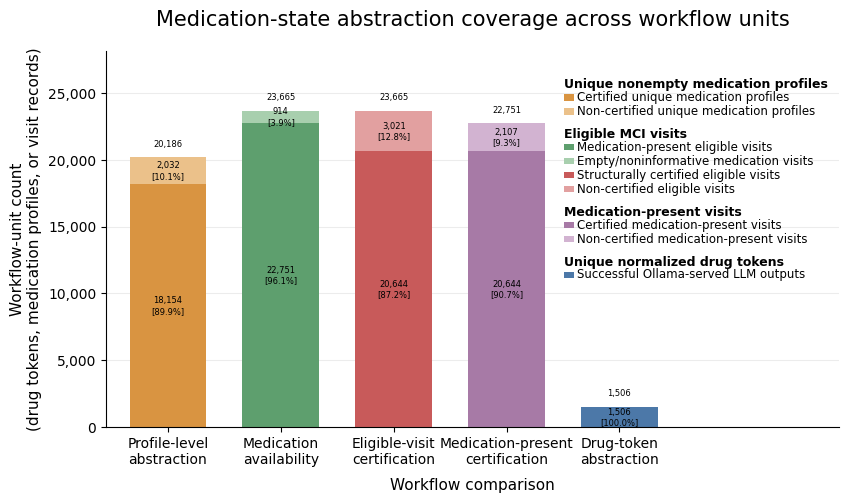

Figure. Medication-state abstraction coverage across workflow units. Bars are shown on the count scale, with one bar per workflow comparison where possible. The visit-level analytic cohort is represented by two bars because medication availability and eligible-visit certification are separate comparisons. Legend headers identify the denominator for each set of colored components.

Saved: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_right_cropped.png
Saved: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_right_cropped.pdf


In [4]:
# Count-scale workflow coverage plot with smoother colors, compact inside legend, and right-cropped output.
# Legend is moved slightly right compared with the prior version and ordered to match the plotted workflow comparisons.
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker
from PIL import Image

# Smooth, muted color palette.
profile_color = ('#D99441', '#EBC18A')
availability_color = ('#5E9F6E', '#A8CFAE')
eligible_cert_color = ('#C85A5A', '#E2A0A0')
med_present_cert_color = ('#A77AA6', '#D2B3D1')
drug_token_color = ('#4C78A8', '#A7C0DD')

bars = pd.DataFrame([
    {
        'x_label': 'Profile-level\nabstraction',
        'denom_count': unique_profiles,
        'lower_count': cert_profiles,
        'upper_count': noncert_profiles,
        'lower_color': profile_color[0],
        'upper_color': profile_color[1],
    },
    {
        'x_label': 'Medication\navailability',
        'denom_count': eligible_visits,
        'lower_count': med_present_visits,
        'upper_count': empty_visits,
        'lower_color': availability_color[0],
        'upper_color': availability_color[1],
    },
    {
        'x_label': 'Eligible-visit\ncertification',
        'denom_count': eligible_visits,
        'lower_count': cert_visits,
        'upper_count': noncert_visits,
        'lower_color': eligible_cert_color[0],
        'upper_color': eligible_cert_color[1],
    },
    {
        'x_label': 'Medication-present\ncertification',
        'denom_count': med_present_visits,
        'lower_count': cert_med_present,
        'upper_count': noncert_med_present,
        'lower_color': med_present_cert_color[0],
        'upper_color': med_present_cert_color[1],
    },
    {
        'x_label': 'Drug-token\nabstraction',
        'denom_count': unique_tokens,
        'lower_count': success_tokens,
        'upper_count': failed_tokens,
        'lower_color': drug_token_color[0],
        'upper_color': drug_token_color[1],
    },
])

bars['lower_percent'] = bars['lower_count'] / bars['denom_count'] * 100
bars['upper_percent'] = bars['upper_count'] / bars['denom_count'] * 100
bars.to_csv(OUTPUT_DIR / 'one_bar_when_possible_smooth_colors_values.csv', index=False)
display(bars)

fig, ax = plt.subplots(figsize=(8.6, 5.0))
x = np.arange(len(bars))
width = 0.68
stack_edge_color = "#1F3A5F"  # dark blue
stack_edge_width = 0.001

for i, row in bars.iterrows():
    ax.bar(i, row['lower_count'], width=width, color=row['lower_color'], edgecolor=stack_edge_color, linewidth=stack_edge_width)
    if row['upper_count'] > 0:
        ax.bar(
            i,
            row['upper_count'],
            bottom=row['lower_count'],
            width=width,
            color=row['upper_color'],
            edgecolor= stack_edge_color,
            linewidth= stack_edge_width,
        )

inside_fontsize = 6.0
top_fontsize = 6.0
for i, row in bars.iterrows():
    ax.text(
        i,
        row['lower_count'] / 2,
        f"{int(row['lower_count']):,}\n[{row['lower_percent']:.1f}%]",
        ha='center',
        va='center',
        fontsize=inside_fontsize,
    )
    if row['upper_count'] > 0:
        ax.text(
            i,
            row['lower_count'] + row['upper_count'] / 2,
            f"{int(row['upper_count']):,}\n[{row['upper_percent']:.1f}%]",
            ha='center',
            va='center',
            fontsize=inside_fontsize,
        )
    ax.text(
        i,
        row['denom_count'] + 650,
        f"{int(row['denom_count']):,}",
        ha='center',
        va='bottom',
        fontsize=top_fontsize,
    )

ax.set_xticks(x)
ax.set_xticklabels(bars['x_label'], fontsize=10)
ax.set_xlim(-0.55, 5.95)
ax.set_ylabel('Workflow-unit count\n(drug tokens, medication profiles, or visit records)', fontsize=11)
ax.set_xlabel('Workflow comparison', fontsize=11, labelpad=8)
ax.set_title('Medication-state abstraction coverage across workflow units', fontsize=15, pad=18)
ax.set_ylim(0, max(bars['denom_count']) * 1.19)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5000))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', alpha=0.23)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move legend slightly right and keep it compact.
# legax = ax.inset_axes([0.635, 0.32, 0.26, 0.64])
legax = ax.inset_axes([0.625, 0.30, 0.32, 0.64])
legax.set_axis_off()

legend_groups = [
    ('Unique nonempty medication profiles', [
        ('Certified unique medication profiles', profile_color[0]),
        ('Non-certified unique medication profiles', profile_color[1]),
    ]),
    ('Eligible MCI visits', [
        ('Medication-present eligible visits', availability_color[0]),
        ('Empty/noninformative medication visits', availability_color[1]),
        ('Structurally certified eligible visits', eligible_cert_color[0]),
        ('Non-certified eligible visits', eligible_cert_color[1]),
    ]),
    ('Medication-present visits', [
        ('Certified medication-present visits', med_present_cert_color[0]),
        ('Non-certified medication-present visits', med_present_cert_color[1]),
    ]),
    ('Unique normalized drug tokens', [
        ('Successful Ollama-served LLM outputs', drug_token_color[0]),
    ]),
]

x0 = 0.00
y = 0.98
header_gap = 0.080
row_h = 0.058
group_gap = 0.025
underline_offset = 0.080  # larger value moves underline lower

for header, items in legend_groups:
    header_y = y
    legax.text(x0, header_y, header, transform=legax.transAxes, ha='left', va='top', fontsize=9.0, fontweight='bold')

    # Removed the under line
    # legax.plot([x0, 0.80],[header_y - underline_offset, header_y - underline_offset], color="black", linewidth=0.65, transform=legax.transAxes, clip_on=False,)

    yy = header_y - header_gap
    for label, color in items:
        legax.add_patch(Rectangle((x0, yy - 0.014), 0.040, 0.026, facecolor=color, edgecolor='none', transform=legax.transAxes))
        legax.text(x0 + 0.055, yy, label, transform=legax.transAxes, ha='left', va='center', fontsize=8.45)
        yy -= row_h

    y = yy - group_gap + row_h * 0.25

caption = (
    'Figure. Medication-state abstraction coverage across workflow units. Bars are shown on the count scale, with one bar per workflow comparison where possible. '
    'The visit-level analytic cohort is represented by two bars because medication availability and eligible-visit certification are separate comparisons. '
    'Legend headers identify the denominator for each set of colored components.'
)

plt.tight_layout(pad=0.6)

# Save temporary full-width PNG, then crop right-side whitespace without changing the plotted layout.
full_png = OUTPUT_DIR / 'fig_med_state_workflow_smooth_colors_full_width.png'
out_png = OUTPUT_DIR / 'fig_med_state_workflow_smooth_colors_right_cropped.png'
out_pdf = OUTPUT_DIR / 'fig_med_state_workflow_smooth_colors_right_cropped.pdf'
fig.savefig(full_png, dpi=300, bbox_inches='tight')

img = Image.open(full_png).convert('RGB')
arr = np.asarray(img)
nonwhite = (arr[:, :, 0] < 220) | (arr[:, :, 1] < 220) | (arr[:, :, 2] < 220)
cols = nonwhite.sum(axis=0)
content_cols = np.where(cols > 5)[0]
right = min(img.width, int(content_cols.max() + 70))
cropped = img.crop((0, 0, right, img.height))
cropped.save(out_png)
cropped.save(out_pdf, 'PDF', resolution=300.0)

plt.show()

with open(OUTPUT_DIR / 'fig_med_state_workflow_smooth_colors_right_cropped_caption.txt', 'w', encoding='utf-8') as f:
    f.write(caption + '\n')

display(Markdown(caption))
print('Saved:', out_png)
print('Saved:', out_pdf)


In [5]:
print('Generated files')
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path.relative_to(PROJECT_ROOT))

Generated files
- op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_full_width.png
- op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_right_cropped.pdf
- op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_right_cropped.png
- op/1_med_state_profiles_stacked/fig_med_state_workflow_smooth_colors_right_cropped_caption.txt
- op/1_med_state_profiles_stacked/one_bar_when_possible_smooth_colors_values.csv
- op/1_med_state_profiles_stacked/true_stacked_bar_values.csv
